## Exploring Tesla Deliveries and Production Data

This notebook delves into Tesla's delivery and production data, analyzing trends, distributions, and leveraging machine learning models to predict future deliveries. Let's uncover some interesting insights!

### Library Imports

This cell imports all necessary libraries for data manipulation, visualization, and machine learning, including `kagglehub`, `pandas`, `numpy`, `matplotlib`, `sklearn` modules for model selection, linear regression, random forest, and evaluation metrics.

In [61]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


## Data Loading and Initial Inspection

This section focuses on loading the dataset, understanding its basic structure, checking for missing values, and performing initial statistical analysis.

In [62]:
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Path to dataset files: /kaggle/input/tesla-ea-deliveries-and-production-data20152025


### Dataset Download

The `kagglehub.dataset_download` function is used here to download the Tesla deliveries and production dataset, and the path to the downloaded files is printed.

In [63]:
df= pd.read_csv(path+"/tesla_deliveries_dataset_2015_2025.csv")

### Load Data and Display Head

This code loads the downloaded CSV file into a pandas DataFrame named `df` and displays the first 5 rows to provide a quick overview of the data structure and content.

In [64]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Understanding Dataset Structure

### Data Information Overview (df.info())

The `df.info()` method is used to print a concise summary of the DataFrame, including the column names, their data types, the number of non-null values, and memory usage. This is crucial for understanding the dataset's completeness and structure.

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


Statistical Data Analysis

### Statistical Summary (df.describe())

This cell generates descriptive statistics of the numerical columns in the DataFrame `df`, providing insights into the central tendency, dispersion, and shape of the distribution of each column (e.g., count, mean, standard deviation, min, max, and quartiles).

In [66]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


### Missing Value Detection

This command checks for any missing values across all columns in the DataFrame. `df.isnull().sum()` returns a Series indicating the count of null values for each column, which is essential for data cleaning.

In [67]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


## Exploratory Data Analysis (EDA)

In this section, we'll dive deeper into the data to uncover patterns, trends, and relationships using various visualizations and aggregations. This helps us understand the distribution of models, regional price differences, and delivery trends over time.

### Model Distribution Analysis

This cell analyzes the distribution of Tesla models by counting the occurrences of each model in the 'Model' column. `value_counts()` is a useful method for understanding the frequency of categorical data.

In [68]:
#SUM OF ALL MODELS SOLD
df["Model"].value_counts()

,count
Model,
Model S,528
Model X,528
Model 3,528
Model Y,528
Cybertruck,528


### Average Price by Region

This code calculates the average price of Tesla vehicles (`Avg_Price_USD`) grouped by 'Region', providing insights into price variations across different geographical areas.

In [69]:
df.groupby("Region")["Avg_Price_USD"].mean()

,Avg_Price_USD
Region,
Asia,85161.733773
Europe,86107.731939
Middle East,84535.999091
North America,83823.896515


### Annual Delivery Trends

This cell calculates the total estimated deliveries of Tesla vehicles for each 'Year' and prints the result, showing the annual delivery trends.

In [70]:
year = df.groupby("Year")["Estimated_Deliveries"].sum()
print(year)

Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64


### Battery Capacity vs. Range Visualization

This scatter plot visualizes the relationship between 'Battery_Capacity_kWh' and 'Range_km'. It helps to understand how battery capacity influences the driving range of Tesla vehicles.

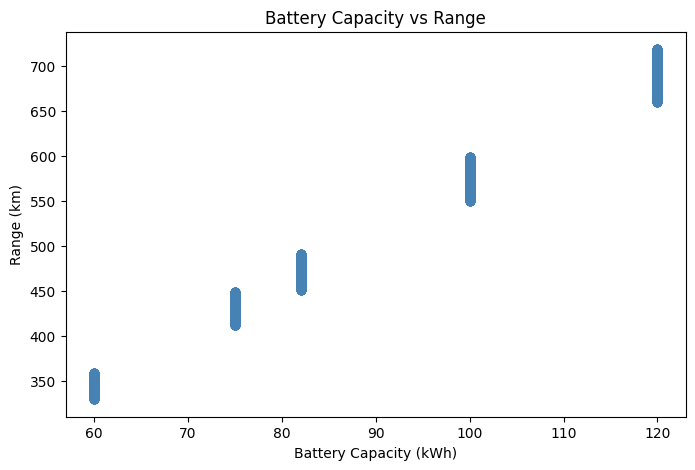

In [71]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Battery_Capacity_kWh"],
    df["Range_km"],
    c='steelblue'
)
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Range (km)")
plt.title("Battery Capacity vs Range")

plt.show()

### Historical Delivery Trend Plot

This cell generates a line plot showing the trend of Tesla's estimated deliveries over the years. It first groups the data by 'Year' and sums the 'Estimated_Deliveries', then plots this time series to highlight delivery growth or decline.

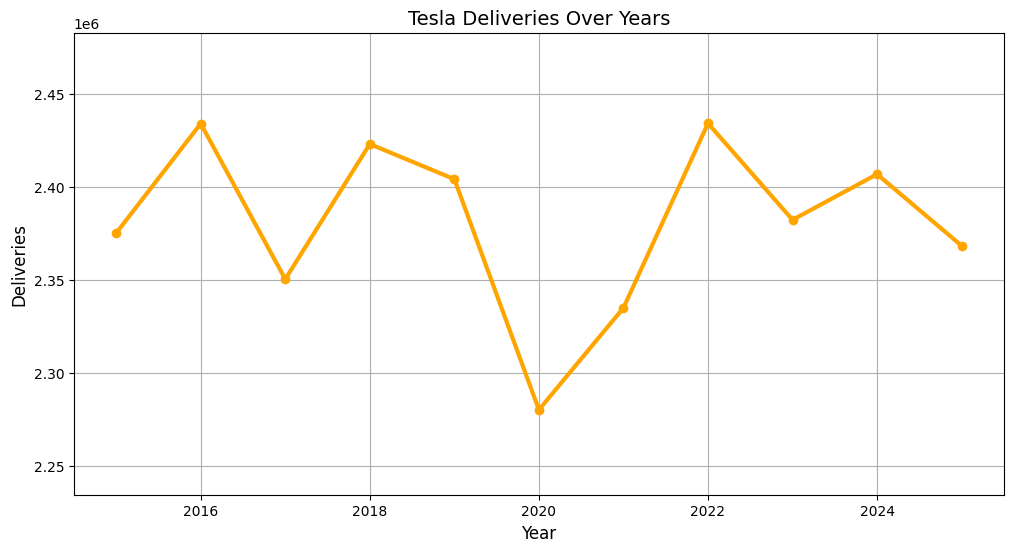

In [72]:
yearly = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(12,6))

plt.plot(
    yearly.index,
    yearly.values,
    marker="o",
    linewidth=3,
    color='orange'
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Deliveries", fontsize=12)
plt.title("Tesla Deliveries Over Years", fontsize=14)

plt.grid(True)

# Zoom in on the interesting range
plt.ylim(
    yearly.min() * 0.98,
    yearly.max() * 1.02
)

plt.show()

### Price Distribution Histogram

This histogram displays the distribution of 'Avg_Price_USD' for Tesla vehicles. It helps to visualize the frequency of different price ranges and understand the overall pricing structure.

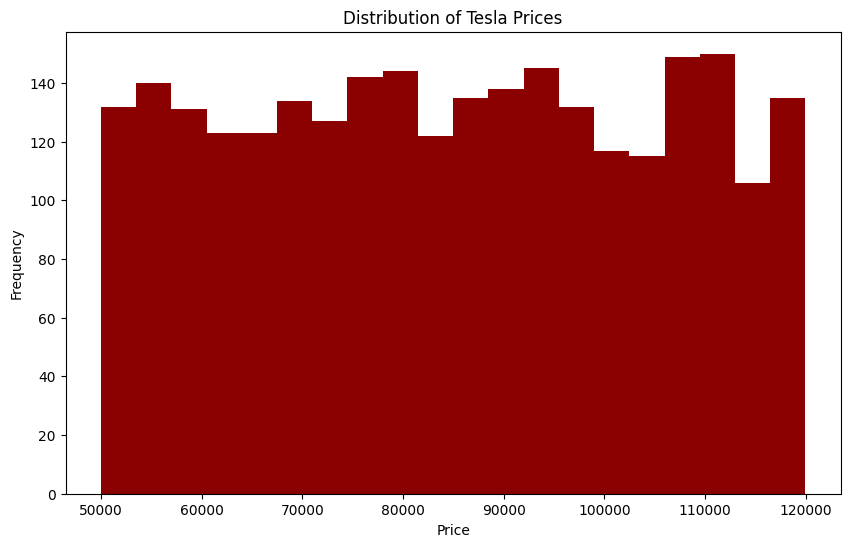

In [73]:
plt.figure(figsize=(10,6))

plt.hist(df["Avg_Price_USD"], bins=20, color='darkred')

plt.title("Distribution of Tesla Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Regional Delivery Share Pie Chart

This pie chart illustrates the proportion of Tesla deliveries across different 'Region's. It groups the data by 'Region' and sums the 'Estimated_Deliveries' to show regional market share.

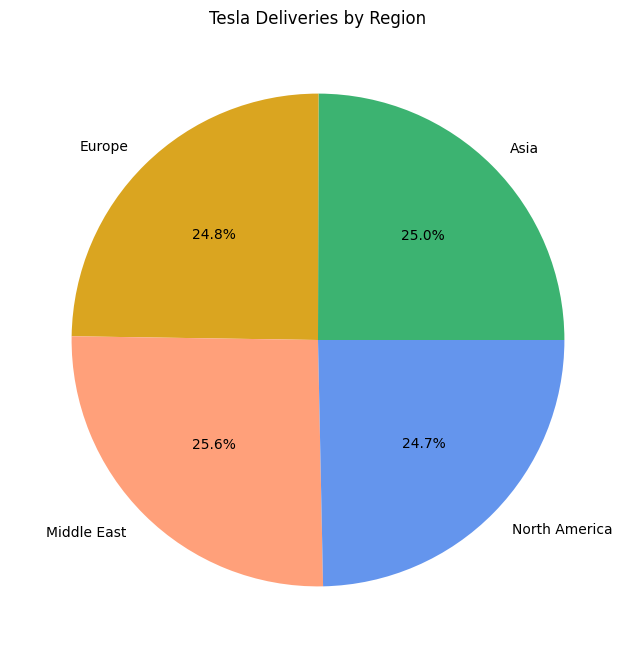

In [74]:
region_sales = df.groupby("Region")["Estimated_Deliveries"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct="%1.1f%%",
    colors=['mediumseagreen', 'goldenrod', 'lightsalmon', 'cornflowerblue']
)

plt.title("Tesla Deliveries by Region")

plt.show()

### Monthly Delivery Heatmap

This heatmap visualizes monthly delivery patterns over the years. It creates a pivot table with 'Year' as index, 'Month' as columns, and 'Estimated_Deliveries' as values, then uses `imshow` to display the delivery magnitude as color intensity.

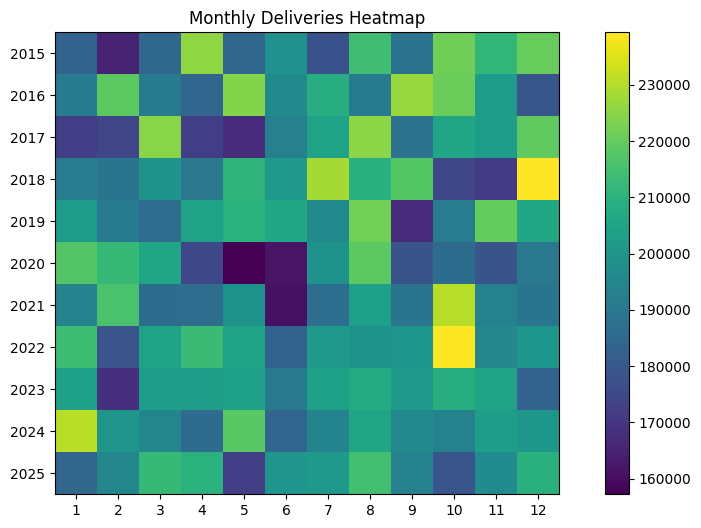

In [75]:
pivot = df.pivot_table(
    values="Estimated_Deliveries",
    index="Year",
    columns="Month",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))

plt.imshow(pivot, cmap='viridis')

plt.colorbar()

plt.xticks(range(12), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title("Monthly Deliveries Heatmap")

plt.show()

## Machine Learning Model Development

This section details the process of building and evaluating machine learning models to predict Tesla deliveries. We'll cover feature selection, splitting data, training different regression models, hyperparameter tuning, and comparing their performance.

In [76]:
X = df[[
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]]

y = df["Estimated_Deliveries"]

### Feature and Target Variable Definition

This cell defines the feature matrix `X` and the target variable `y` for machine learning. `X` includes various numerical features like year, month, production units, average price, battery capacity, range, CO2 saved, and charging stations, while `y` is the 'Estimated_Deliveries'.

### Model Training and Prediction

Here, we'll split the data into training and testing sets, then train both a Linear Regression model and a Random Forest Regressor on the training data. After training, we'll make predictions on the test set.

### Train-Test Split

Here, the dataset is split into training and testing sets using `train_test_split`. 80% of the data is used for training (`X_train`, `y_train`) and 20% for testing (`X_test`, `y_test`), ensuring that the model's performance can be evaluated on unseen data. The shapes of the resulting sets are printed to confirm the split.

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(2112, 8)
(528, 8)


### Linear Regression Model Training

This cell initializes and trains a Linear Regression model using the training data (`X_train`, `y_train`). Linear Regression is a fundamental supervised learning algorithm used for predicting a continuous target variable.

In [78]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

### Linear Regression Prediction

After training, the Linear Regression model (`lr`) is used to make predictions (`lr_pred`) on the test dataset (`X_test`).

In [79]:
lr_pred = lr.predict(X_test)

### Linear Regression Model Evaluation

This cell evaluates the performance of the Linear Regression model by calculating the R2 score and Mean Absolute Error (MAE) between the actual test deliveries (`y_test`) and the predicted deliveries (`lr_pred`). These metrics help assess how well the model fits the data and its prediction accuracy.

In [80]:
print("Linear Regression")

print("R2:",
      r2_score(y_test, lr_pred))

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

Linear Regression
R2: 0.9901595854768158
MAE: 309.708165264122


### Random Forest Model Training

This cell initializes and trains a Random Forest Regressor model using the training data. Random Forest is an ensemble learning method that builds multiple decision trees and merges their predictions to improve accuracy and control overfitting.

In [81]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### Random Forest Prediction

The trained Random Forest model (`rf`) is used to make predictions (`rf_pred`) on the test dataset (`X_test`).

In [82]:
rf_pred = rf.predict(X_test)

### Random Forest Model Evaluation

This cell evaluates the performance of the Random Forest model by calculating the R2 score and Mean Absolute Error (MAE) between the actual test deliveries (`y_test`) and the predicted deliveries (`rf_pred`). This provides a comparison with the Linear Regression model.

In [83]:
print("Random Forest")

print("R2:",
      r2_score(y_test, rf_pred))

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

Random Forest
R2: 0.9893103793226311
MAE: 314.13619318181816


### Hyperparameter Tuning

This step involves optimizing the Random Forest Regressor's performance by systematically searching for the best combination of hyperparameters using GridSearchCV.

### Hyperparameter Tuning with GridSearchCV

This cell performs hyperparameter tuning for the Random Forest Regressor using `GridSearchCV`. It defines a grid of hyperparameters (`n_estimators`, `max_depth`, `min_samples_split`) and searches for the best combination that maximizes the R2 score through cross-validation. The best parameters found are then printed.

In [84]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


### Best Random Forest Model Prediction

After identifying the best hyperparameters from `GridSearchCV`, this cell retrieves the best performing Random Forest estimator (`best_rf`) and uses it to make predictions (`best_pred`) on the test set.

In [85]:
best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

### Tuned Random Forest Model Evaluation

This cell evaluates the performance of the hyperparameter-tuned Random Forest model by calculating its R2 score and Mean Absolute Error (MAE). This helps determine if tuning improved the model's performance compared to the default Random Forest.

In [86]:
print("Tuned RF")

print("R2:",
      r2_score(y_test, best_pred))

print("MAE:",
      mean_absolute_error(y_test, best_pred))

Tuned RF
R2: 0.9894521149703156
MAE: 311.9404924242424


### Model Comparison and Feature Importance

Finally, we'll compare the performance of all trained models using R2 score and evaluate the feature importance from the best-performing model to understand which factors most influence Tesla deliveries.

### Model Performance Comparison (R2 Scores)

This cell creates a dictionary to store and display the R2 scores for all three models: Linear Regression, standard Random Forest, and the hyperparameter-tuned Random Forest. This provides a clear summary for model comparison.

In [87]:
comparison = {
    "Linear Regression":
        r2_score(y_test, lr_pred),

    "Random Forest":
        r2_score(y_test, rf_pred),

    "Tuned Random Forest":
        r2_score(y_test, best_pred)
}

print(comparison)

{'Linear Regression': 0.9901595854768158, 'Random Forest': 0.9893103793226311, 'Tuned Random Forest': 0.9894521149703156}


### R2 Score Visualization

This bar chart visually compares the R2 scores of the different machine learning models used. It plots the R2 score for Linear Regression, Random Forest, and Tuned Random Forest, making it easy to identify the best-performing model.

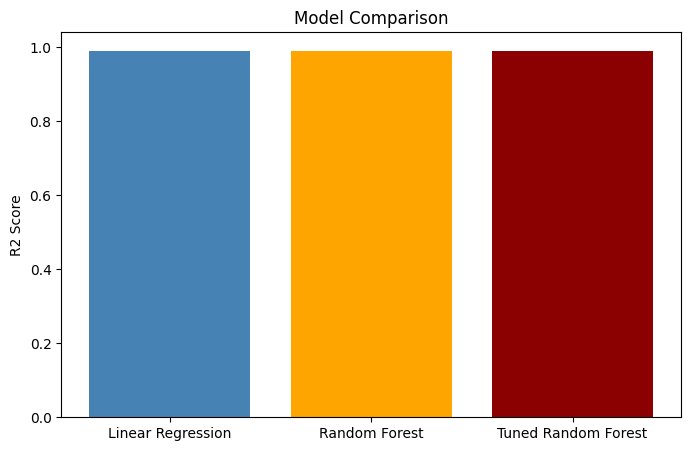

In [88]:
models = comparison.keys()
scores = comparison.values()

plt.figure(figsize=(8,5))

plt.bar(models, scores, color=['steelblue', 'orange', 'darkred'])

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

### Feature Importance Analysis

This cell calculates and displays the feature importance from the best-tuned Random Forest model. It helps identify which features (`Year`, `Month`, `Production_Units`, etc.) contributed most to the model's predictions, providing valuable insights into the drivers of Tesla deliveries.

In [89]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
        best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                Feature  Importance
2      Production_Units    0.990923
6        CO2_Saved_tons    0.002625
5              Range_km    0.001650
3         Avg_Price_USD    0.001488
7     Charging_Stations    0.001301
0                  Year    0.000955
1                 Month    0.000861
4  Battery_Capacity_kWh    0.000196


### Data Preparation for Time Series

First, we'll create a proper 'Date' column and aggregate deliveries on a monthly basis to prepare the data for time series modeling.

## Time Series Forecasting

This section focuses on forecasting future Tesla deliveries using time-series techniques. We'll prepare the data for time-series analysis, build a simple forecasting model, and project future delivery numbers.

### Date Column Creation

This cell creates a new 'Date' column in the DataFrame by combining the 'Year' and 'Month' columns and converting them to a datetime format. This new column is essential for time-series analysis.

In [90]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str)
)
print(df[["Year","Month","Date"]].head())

   Year  Month       Date
0  2023      5 2023-05-01
1  2015      2 2015-02-01
2  2019      1 2019-01-01
3  2021      2 2021-02-01
4  2016     12 2016-12-01


### Monthly Delivery Aggregation

This cell aggregates the 'Estimated_Deliveries' on a monthly basis. It groups the DataFrame by the newly created 'Date' column and sums the deliveries for each month, then resets the index to create a new DataFrame `monthly`.

In [91]:
monthly = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .reset_index()
)
print(monthly.head())

        Date  Estimated_Deliveries
0 2015-01-01                183180
1 2015-02-01                165053
2 2015-03-01                184567
3 2015-04-01                225623
4 2015-05-01                184264


### Time Series Plot of Deliveries

This line plot visualizes Tesla's estimated deliveries over time, using the 'Date' column from the `monthly` DataFrame. This helps to identify any temporal trends, seasonality, or anomalies in the delivery data.

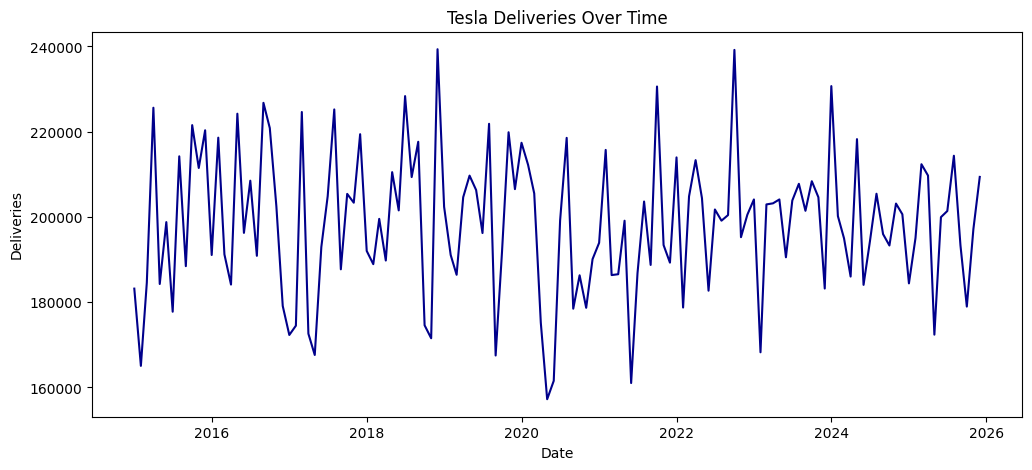

In [92]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Date"],
    monthly["Estimated_Deliveries"],
    color='darkblue'
)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

### Time Feature Creation

This cell adds a 'Time' column to the `monthly` DataFrame, which is a numerical representation of the time steps. This is often used as a feature for time-series forecasting models.

In [93]:
monthly["Time"] = np.arange(len(monthly))

### Linear Regression for Time Series Forecasting

A simple linear regression model will be used to capture the trend in monthly deliveries and make initial predictions.

### Time Series Linear Regression Model Training

Here, a simple Linear Regression model is fitted to forecast future deliveries based on the 'Time' variable. The 'Time' column serves as the independent variable (`X`), and 'Estimated_Deliveries' as the dependent variable (`y`). The model then predicts future deliveries based on this linear relationship.

In [94]:
X = monthly[["Time"]]
y = monthly["Estimated_Deliveries"]

model = LinearRegression()

model.fit(X, y)
monthly["Predicted"] = model.predict(X)

### Generating Future Forecasts

We'll extend our time steps into the future and use the trained linear regression model to predict deliveries for the upcoming months.

In [95]:
future_time = np.arange(
    len(monthly),
    len(monthly)+12
).reshape(-1,1)

forecast = model.predict(future_time)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Future Time Step Generation and Prediction

This cell generates future time steps for the next 12 months, starting from the end of the existing 'Time' series. These future time steps (`future_time`) are then used by the trained Linear Regression model to forecast deliveries for those periods.

In [96]:
future_dates = pd.date_range(
    start=monthly["Date"].max(),
    periods=13,
    freq="ME"
)[1:]

### Future Date Range Generation

This cell creates a range of future dates corresponding to the forecast horizon (12 months). It starts from the maximum date in the `monthly` DataFrame and generates 12 subsequent month-end dates.

### Displaying Forecast Results

This final step compiles the forecasted deliveries with their corresponding dates into a readable DataFrame.

In [97]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast
})

print(forecast_df)

         Date       Forecast
0  2026-01-31  198436.571015
1  2026-02-28  198436.459415
2  2026-03-31  198436.347815
3  2026-04-30  198436.236215
4  2026-05-31  198436.124615
5  2026-06-30  198436.013015
6  2026-07-31  198435.901415
7  2026-08-31  198435.789815
8  2026-09-30  198435.678214
9  2026-10-31  198435.566614
10 2026-11-30  198435.455014
11 2026-12-31  198435.343414


### Display Forecasted Deliveries

Finally, this cell combines the generated `future_dates` with the `forecast` values into a new DataFrame called `forecast_df` and prints it. This DataFrame clearly presents the predicted Tesla deliveries for the upcoming months.